# Semantic Segmentation of Pet Images with U-NET

In this notebook we implement **semantic segmentation** on the Oxford-IIIT Pet dataset using a compact **U-NET** style model.

We are performing a 3-class segmentation (background / pet / border) or optional binary segmentation (pet vs background).
The model is a U-Net with a pretrained ResNet-34 encoder for fast convergence. 


In [ ]:
# import necessary libraries

import os, random, math, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms

import matplotlib.pyplot as plt

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


torch: 2.8.0+cu128
torchvision: 0.23.0+cu128
device: cuda


# 1. Loading and Preparing the Pet Dataset

TorchVision provides a built-in dataset wrapper with `target_types='segmentation'` which yields the trimap mask.
See docs: https://docs.pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html


In [2]:
ROOT = Path('data/oxford-iiit-pet')
IMG_SIZE = 256  # increase to 320 for slightly sharper masks (needs more VRAM)
BATCH_SIZE = 16 if torch.cuda.is_available() else 4
NUM_WORKERS = 2

# Choose task mode:
MODE = 'trimap'  # 'trimap' (3 classes: background/pet/border) or 'binary' (pet vs background)

# Torchvision returns a PIL image for both image and segmentation target
img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# We'll convert mask to tensor in our wrapper to keep class IDs intact
base_ds = torchvision.datasets.OxfordIIITPet(
    root=str(ROOT),
    split='trainval',
    target_types='segmentation',
    download=True,
)

class PetSeg(Dataset):
    def __init__(self, base, mode='trimap'):
        self.base = base
        self.mode = mode

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, mask = self.base[idx]
        img = img_tf(img)

        # mask is a PIL image with trimap values in {1,2,3}
        mask = transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.NEAREST)(mask)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)

        # Convert from {1,2,3} to {0,1,2}
        mask = mask - 1

        if self.mode == 'binary':
            # pet=1 for class 1 (pet) and optionally treat border as pet as well
            pet = (mask == 1) | (mask == 2)
            mask = pet.long()  # {0,1}
        return img, mask

ds = PetSeg(base_ds, mode=MODE)

# Split into train/val for early stopping
val_frac = 0.15
n_val = int(len(ds) * val_frac)
n_train = len(ds) - n_val
train_ds, val_ds = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('train:', len(train_ds), 'val:', len(val_ds))


train: 3128 val: 552


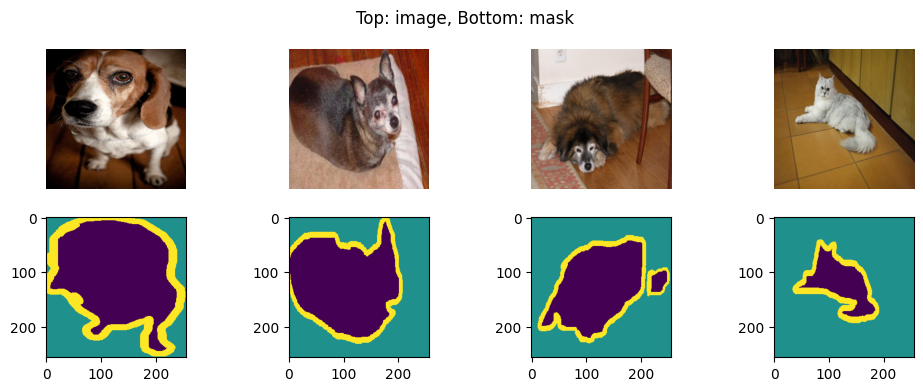

In [3]:
# Quick sanity-check visualization
def denorm(x):
    mean = torch.tensor([0.485, 0.456, 0.406])[:,None,None]
    std  = torch.tensor([0.229, 0.224, 0.225])[:,None,None]
    return (x.cpu()*std + mean).clamp(0,1)

imgs, masks = next(iter(train_loader))
plt.figure(figsize=(12,4))
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(denorm(imgs[i]).permute(1,2,0))
    plt.axis('off')
    plt.subplot(2,4,4+i+1)
    plt.imshow(masks[i].cpu(), vmin=0, vmax=(2 if MODE=='trimap' else 1))
    #plt.axis('off')
plt.suptitle('Top: image, Bottom: mask')
plt.show()


# 2. Building the U-NET Model Architecture 

Now that we have loaded our data, we can define our U-NET architecture. Remember that U-NET consists of a contracting path to capture context and a symmetric expanding path that enables precise localization:

<img src="images/UNET.png"  height=60% width=60% />

Here, we use a U-Net style decoder with a **pretrained ResNet-34 encoder** for fast convergence. This means we reuse ResNet’s already learned image features (edges → textures → object parts) as the encoder, and we only train a new decoder head that upsamples these features back to full resolution to predict a class label for every pixel. We also tap intermediate ResNet feature maps as skip connections, so the decoder can recover fine details like object boundaries.

Let's take a look at the encoder structure we will use below for a better understanding:


In [4]:
from torchvision.models import resnet34, ResNet34_Weights
enc = resnet34(weights=ResNet34_Weights.DEFAULT)
print(enc)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  


**TODO**: Complete the ConvBNReLU block. It should consist of a Conv2d layer using the function arguments (with no bias), followed by a BatchNorm2d layer and a ReLU activation. We will call this block multiple times in the U-Net upsampling path.

In [5]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(

            # YOUR CODE HERE
            nn.Conv2d(in_ch, out_ch, k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            # END STUDENT CODE

        )
    def forward(self, x):
        return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv1 = ConvBNReLU(out_ch + skip_ch, out_ch)
        self.conv2 = ConvBNReLU(out_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        # align sizes if needed (odd sizes)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv2(self.conv1(x))
        return x

class ResNetUNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        enc = resnet34(weights=ResNet34_Weights.DEFAULT)


        # Encoder stages (ResNet-34 backbone)
        # Input x: (B, 3, 256, 256)

        self.stem = nn.Sequential(enc.conv1, enc.bn1, enc.relu)
        # conv1 has stride=2  -> spatial: 256 -> 128
        # s0: (B, 64, 128, 128)

        self.pool = enc.maxpool
        # maxpool stride=2    -> spatial: 128 -> 64
        # after pool: (B, 64, 64, 64)

        self.e1 = enc.layer1
        # layer1 stride=1     -> spatial stays 64
        # s1: (B, 64, 64, 64)

        self.e2 = enc.layer2
        # layer2 first block stride=2 -> spatial: 64 -> 32
        # s2: (B, 128, 32, 32)

        self.e3 = enc.layer3
        # layer3 first block stride=2 -> spatial: 32 -> 16
        # s3: (B, 256, 16, 16)

        self.e4 = enc.layer4
        # layer4 first block stride=2 -> spatial: 16 -> 8
        # x (bottleneck): (B, 512, 8, 8)

        # Decoder (U-Net style upsampling + skip connections)
        self.d3 = UpBlock(in_ch=512, skip_ch=256, out_ch=256)
        # upsample: 8 -> 16, concat with s3 -> channels 256+256=512, then conv -> (B, 256, 16, 16)

        self.d2 = UpBlock(in_ch=256, skip_ch=128, out_ch=128)
        # upsample: 16 -> 32, concat with s2 -> channels 128+128=256, then conv -> (B, 128, 32, 32)

        self.d1 = UpBlock(in_ch=128, skip_ch=64, out_ch=64)
        # upsample: 32 -> 64, concat with s1 -> channels 64+64=128, then conv -> (B, 64, 64, 64)

        self.d0 = UpBlock(in_ch=64, skip_ch=64, out_ch=32)
        # upsample: 64 -> 128, concat with s0 -> channels 32+64=96, then conv -> (B, 32, 128, 128)

        self.head = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            # upsample: 128 -> 256 -> (B, 16, 256, 256)
            nn.ReLU(inplace=True),
            nn.Conv2d(16, num_classes, kernel_size=1)
            # class logits per pixel -> (B, num_classes, 256, 256)
        )

    def forward(self, x):
            
        # x: (B, 3, 256, 256)
        s0 = self.stem(x)       # (B, 64, 128, 128)
        x  = self.pool(s0)      # (B, 64, 64, 64)
        s1 = self.e1(x)         # (B, 64, 64, 64)
        s2 = self.e2(s1)        # (B, 128, 32, 32)
        s3 = self.e3(s2)        # (B, 256, 16, 16)
        x  = self.e4(s3)        # (B, 512, 8, 8)

        x = self.d3(x, s3)      # (B, 256, 16, 16)
        x = self.d2(x, s2)      # (B, 128, 32, 32)
        x = self.d1(x, s1)      # (B, 64, 64, 64)
        x = self.d0(x, s0)      # (B, 32, 128, 128)
        x = self.head(x)        # (B, num_classes, 256, 256)
        return x

NUM_CLASSES = 3 if MODE=='trimap' else 2
model = ResNetUNet(NUM_CLASSES).to(device)
print('num classes:', NUM_CLASSES)


num classes: 3


**TODO:** Take a moment to verify that the dimensions in the comments above are correct! Compare with the printed the Resnet architecture above to find out what the components and their dimensions are. 

## 3) Loss, Metrics, Early Stopping

For segmentation we combine a pixelwise classification loss with **Dice**, which directly measures region overlap.
Dice for one class (c) is

$$
\mathrm{Dice}_c=\frac{2\sum_i P_{c,i}T_{c,i}}{\sum_i P_{c,i}+\sum_i T_{c,i}}
$$

where $P_{c,i}$ are the predicted probabilities for class c at pixel i, and $T_{c,i}$ are the ground truth one-hot labels. We sum over all pixels i in the batch
and we average over classes. In the metric (`dice_score`) we use **hard** masks via `argmax`; in `DiceLoss` we use **soft** probabilities (`softmax`) and optimize

$$
\mathcal{L}=\mathcal{L}_{CE}+0.5(1-\tfrac{1}{C}\sum_c \mathrm{Dice}_c)
$$

(Note that in binary classification, we would use binary cross entropy loss combined with dice loss). Early stopping monitors the validation dice loss (higher is better) and saves the best checkpoint.


In [6]:
def dice_score(logits, targets, num_classes):
    # logits: (B,C,H,W), targets: (B,H,W)
    with torch.no_grad():
        pred = logits.argmax(1) # class predictions
        dice_per_class = []
        for c in range(num_classes):
            p = (pred == c).float() # predicted mask for class c
            t = (targets == c).float() # ground truth mask for class c
            inter = (p*t).sum(dim=(1,2)) # intersection = sum of element-wise multiplication
            union = p.sum(dim=(1,2)) + t.sum(dim=(1,2)) # union = sum of both masks
            dice = (2*inter + 1e-6) / (union + 1e-6) # dice score for class c
            # we add a small constant (1e-6) to the denominator to avoid division by zero
            # we also add a small constant (1e-6) to the numerator to get dice = 1 when both p and t are zero
            dice_per_class.append(dice) 
        dice = torch.stack(dice_per_class, dim=1).mean(dim=1)  # mean over classes
        return dice.mean().item()

class DiceLoss(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
    def forward(self, logits, targets):
        # soft dice over classes
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, num_classes=self.num_classes).permute(0,3,1,2).float()
        inter = (probs * targets_oh).sum(dim=(0,2,3))
        union = probs.sum(dim=(0,2,3)) + targets_oh.sum(dim=(0,2,3))
        dice = (2*inter + 1e-6) / (union + 1e-6)
        return 1 - dice.mean() # return mean dice loss over classes

dice_loss = DiceLoss(NUM_CLASSES)

ce_loss = nn.CrossEntropyLoss()
def loss_fn(logits, targets):
    return ce_loss(logits, targets) + 0.5 * dice_loss(logits, targets) # combined loss

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = -1e9
        self.bad = 0
        self.best_path = None
    def step(self, score, model, path):
        if score > self.best + self.min_delta:
            self.best = score
            self.bad = 0
            torch.save(model.state_dict(), path) # save best model
            self.best_path = path
            return False
        else:
            self.bad += 1 # count bad epochs for early stopping
            return self.bad >= self.patience 


## 4) Training 

In [7]:
EPOCHS = 20
BASE_LR = 1e-4
WEIGHT_DECAY = 1e-4
FREEZE_ENCODER = True  # set False if you want a bit more accuracy (slower convergence)

if FREEZE_ENCODER:
    for p in model.stem.parameters(): p.requires_grad = False
    for p in model.e1.parameters(): p.requires_grad = False
    for p in model.e2.parameters(): p.requires_grad = False
    # keep deeper blocks trainable

params = [p for p in model.parameters() if p.requires_grad]
opt = torch.optim.AdamW(params, lr=BASE_LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)

early = EarlyStopping(patience=5)
ckpt_path = 'best_pet_unet.pt'

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    t0 = time.time()
    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if train:
            opt.zero_grad(set_to_none=True)

            logits = model(imgs)
            loss = loss_fn(logits, masks)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 5.0)
            opt.step()
        else:
            with torch.no_grad():
                logits = model(imgs)
                loss = loss_fn(logits, masks)

        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset), time.time() - t0

history = {'train_loss':[], 'val_loss':[], 'val_dice':[], 'lr':[]}

for epoch in range(1, EPOCHS+1):
    train_loss, t_train = run_epoch(train_loader, train=True)
    val_loss, t_val = run_epoch(val_loader, train=False)

    # val dice
    model.eval()
    dices = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            dices.append(dice_score(logits, masks, NUM_CLASSES))
    val_dice = float(np.mean(dices))

    sched.step(val_dice)
    lr = opt.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['lr'].append(lr)

    print(f"Epoch {epoch:02d}/{EPOCHS} | lr={lr:.2e} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_dice={val_dice:.4f}")

    stop = early.step(val_dice, model, ckpt_path)
    if stop:
        print(f"Early stopping triggered. Best val_dice={early.best:.4f} | ckpt={early.best_path}")
        break

print('Done.')


Epoch 01/20 | lr=1.00e-04 | train_loss=1.1185 | val_loss=0.9271 | val_dice=0.6014


Epoch 02/20 | lr=1.00e-04 | train_loss=0.8394 | val_loss=0.7479 | val_dice=0.6511


Epoch 03/20 | lr=1.00e-04 | train_loss=0.7000 | val_loss=0.6471 | val_dice=0.7990


Epoch 04/20 | lr=1.00e-04 | train_loss=0.5970 | val_loss=0.5392 | val_dice=0.8578


Epoch 05/20 | lr=1.00e-04 | train_loss=0.4772 | val_loss=0.4409 | val_dice=0.8654


...

Epoch 11/20 | lr=1.00e-04 | train_loss=0.1789 | val_loss=0.2781 | val_dice=0.8699


Epoch 12/20 | lr=1.00e-04 | train_loss=0.1636 | val_loss=0.2674 | val_dice=0.8743


Epoch 13/20 | lr=5.00e-05 | train_loss=0.1473 | val_loss=0.2749 | val_dice=0.8731


Epoch 14/20 | lr=5.00e-05 | train_loss=0.1317 | val_loss=0.2688 | val_dice=0.8755


Epoch 15/20 | lr=5.00e-05 | train_loss=0.1197 | val_loss=0.2787 | val_dice=0.8743
Early stopping triggered. Best val_dice=0.8762 | ckpt=best_pet_unet.pt
Done.


**TODO:** Plot the training and validation loss, the dice score and the learning rate over time!

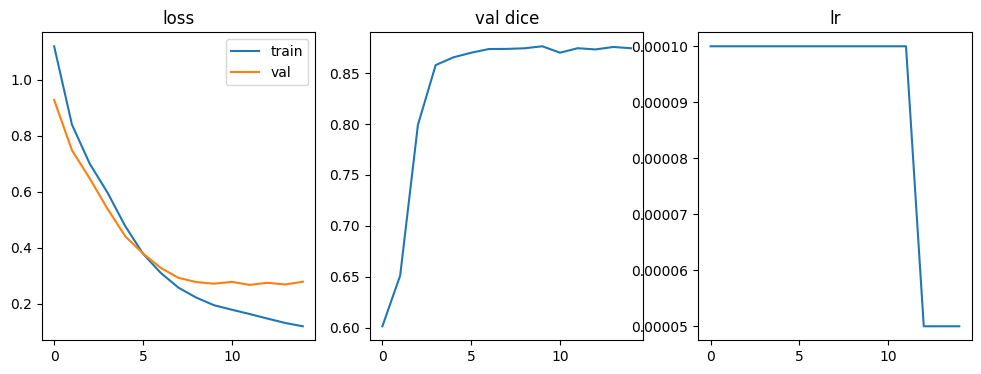

In [ ]:
# YOUR CODE HERE
# Plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(history['val_dice'])
plt.title('val dice')

plt.subplot(1,3,3)
plt.plot(history['lr'])
plt.title('lr')
plt.show()


## 5) Qualitative results

Finally, let's take a look at our results:

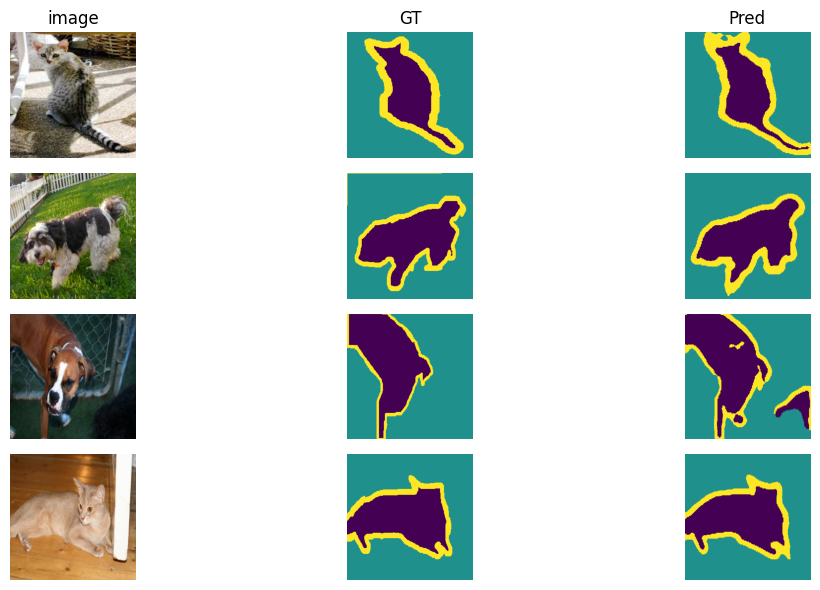

In [9]:
# Load best checkpoint and visualize predictions
model.load_state_dict(torch.load('best_pet_unet.pt', map_location=device))
model.eval()

def predict_mask(img):
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(1).squeeze(0).cpu()
    return pred

imgs, masks = next(iter(val_loader))
plt.figure(figsize=(12,6))
for i in range(4):
    img = imgs[i]
    gt  = masks[i]
    pr  = predict_mask(img)

    plt.subplot(4,3,3*i+1)
    plt.imshow(denorm(img).permute(1,2,0))
    plt.axis('off')
    if i == 0: plt.title('image')

    plt.subplot(4,3,3*i+2)
    plt.imshow(gt.cpu(), vmin=0, vmax=(2 if MODE=='trimap' else 1))
    plt.axis('off')
    if i == 0: plt.title('GT')

    plt.subplot(4,3,3*i+3)
    plt.imshow(pr, vmin=0, vmax=(2 if MODE=='trimap' else 1))
    plt.axis('off')
    if i == 0: plt.title('Pred')

plt.tight_layout()
plt.show()
